In [1]:
import os,sys
import numpy as np
import pandas as pd
import umap
import pickle
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

import scanpy as sc
import anndata
import scanpy.external as sce
from scarches.models.scpoli import scPoli

from sklearn.neighbors import KNeighborsClassifier


mpl.rcParams['figure.dpi'] = 50
mpl.rcParams['pdf.fonttype'] = 42
sc.settings.set_figure_params(facecolor=(0, 0, 0, 0), dpi=50, dpi_save=600)

sns.set_style({'axes.grid': False})

import warnings
warnings.filterwarnings('ignore')

sc.settings.figdir = f'/home/xuq44/projects/hgioa/revision2/figures'
figdir = f'/home/xuq44/projects/hgioa/revision2/figures'


/home/xuq44/miniconda3/envs/scarches/lib/python3.9/site-packages/umap/distances.py:1063: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit()
/home/xuq44/miniconda3/envs/scarches/lib/python3.9/site-packages/umap/distances.py:1071: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit()
/home/xuq44/miniconda3/envs/scarches/lib/python3.9/site-packages/uma

In [2]:
project_dir="/home/xuq44/projects/hgioa/data/revision"
plate_level_all0 = pd.read_csv(f"{project_dir}/scripts/db/gut_scpoli_color.txt",
                sep='\t', header=None, index_col=0)
plate_level_all0['names']=plate_level_all0.index
plate_level_all = plate_level_all0.to_dict()[1]

In [3]:

plate_level_all["type ii pneumocyte"]=plate_level_all["alveolar type 2 (AT2) cells"] 
plate_level_all["type i pneumocyte"]=plate_level_all["alveolar type 1 (AT1) cells"] 
plate_level_all["basal cell"]=plate_level_all["basal cells"] 
plate_level_all["club cell"]=plate_level_all["club cells"]
plate_level_all["respiratory goblet cell"]=plate_level_all["goblet cells"]
plate_level_all["lung ciliated cell"]=plate_level_all["ciliated cells"] 
plate_level_all["serous cell of epithelium of bronchus"]="#686EB1"
plate_level_all["respiratory mucous cell"]="#C05E3F"
plate_level_all["neuroendocrine"]=plate_level_all["neuroendocrine cells"]
plate_level_all["epithelium"]=plate_level_all["stem cells"]
plate_level_all["adult"]="#0073C2"
plate_level_all["fetal"]="#777777"


In [ ]:

def clear_genes(adata):
    clear_genes = pd.read_csv("/home/xuq44/refgenomes/hg38/hg_genes_clear.txt", header=None)[0].tolist()
    malat1 = [i for i in clear_genes if i.startswith('MALAT1')]
    mito_genes = [i for i in clear_genes if i.startswith('MT-')]
    hb_genes = [i for i in clear_genes if i.startswith('^HB[^(P|E|S)]')]
    xist = [i for i in clear_genes if i.startswith('XIST')]
    # clear_genes = [i for i in clear_genes if i not in malat1+mito_genes+hb_genes+xist]
    clear_genes = [i for i in clear_genes if i not in malat1+mito_genes+xist]

    sub_clear_genes = [i for i in clear_genes if i in adata.var.index.tolist()]
    adata = adata[:, sub_clear_genes]
    
    return adata

def run_scpoli(adata_all, celltype_key):
    early_stopping_kwargs = {
        "early_stopping_metric": "val_prototype_loss",
        "mode": "min",
        "threshold": 0,
        "patience": 20,
        "reduce_lr": True,
        "lr_patience": 13,
        "lr_factor": 0.1,
    }

    scpoli_model = scPoli(
        adata=adata_all,
        unknown_ct_names=['nan'],
        condition_key='Batch',
        cell_type_keys=[celltype_key],
        embedding_dim=3,
        hidden_layer_sizes=[int(np.sqrt(adata_all.shape[0]))]
    )

    scpoli_model.train(
        n_epochs=12,
        pretraining_epochs=10,
        early_stopping_kwargs=early_stopping_kwargs,
        eta=10,
        alpha_epoch_anneal=100
    )
    adata_all.obsm["X_scPoli"] = scpoli_model.get_latent(
        adata_all.X, 
        adata_all.obs["Batch"].values,
        mean=True
    )

    ref_path = f'/home/xuq44/projects/hgioa/revision2/data/lung_tissue/scpoli_ref/scpoli_model/'
    scpoli_model.save(ref_path, overwrite=True)

    sc.pp.neighbors(adata_all, use_rep="X_scPoli")
    # sc.tl.leiden(adata_all, resolution=10.0)
    sc.tl.umap(adata_all)

    return adata_all

def umap_quan(adata, use_rep=None):
    if use_rep==None:
        use_rep = 'X'
        model = umap.UMAP(n_neighbors=15, random_state=1, min_dist=0.5).fit(adata.X)
    
    adata.obsm['X_umap'] = model.embedding_
    # adata.uns['umap_model'] = model

    return adata, model


In [5]:
project_dir = "/home/xuq44/projects/hgioa/data/revision/results/tissue_ref"
adata_yu = sc.read_h5ad(f"{project_dir}/yu_atlas/yu_atlas_inti.h5ad")
adata_ts = sc.read_h5ad(f"{project_dir}/ts_atlas/ts_atlas_inti.h5ad")

adata_ts = adata_ts[adata_ts.obs.organ_tissue=='Lung']
adata_yu = adata_yu[adata_yu.obs.tissue=='lung']


In [6]:

ts_use_cts = ["type ii pneumocyte", 
              "type i pneumocyte", 
              "basal cell", 
              "club cell",
              "respiratory goblet cell",
              "lung ciliated cell", 
              "serous cell of epithelium of bronchus",
              "respiratory mucous cell"]

adata_ts = adata_ts[adata_ts.obs.celltype.isin(ts_use_cts)]
adata_ts.obs['source'] = 'adult'


In [7]:

yu_use_cts = {"Distal lung epithelium":'epithelium',
              "Basal like":'basal cell',
              "Ciliated":"lung ciliated cell",
              "MUC2+ goblet":"respiratory goblet cell",
              "Enteroendocrine":"neuroendocrine"}

adata_yu = adata_yu[adata_yu.obs.celltype.isin(yu_use_cts)]
adata_yu.obs['celltype'] = adata_yu.obs.celltype.map(yu_use_cts)

adata_yu.obs['source'] = 'fetal'

In [8]:
adata = anndata.AnnData.concatenate(*[adata_yu, adata_ts], join='outer', fill_value=0)
adata = adata.raw.to_adata()
adata = clear_genes(adata)
adata.obs.Batch = adata.obs.Batch.astype('str')
adata.obs.loc[adata.obs.Batch.isna(), 'Batch'] = adata[adata.obs.Batch.isna()].obs.Sample.tolist()

adata.raw = adata
sc.pp.highly_variable_genes(adata, n_top_genes=3000, batch_key='Batch')
adata = adata[:,adata.var.highly_variable]


In [13]:
adata = run_scpoli(adata, 'celltype')

Embedding dictionary:
 	Num conditions: 4
 	Embedding dim: 3
Encoder Architecture:
	Input Layer in, out and cond: 3000 153 3
	Mean/Var Layer in/out: 153 10
Decoder Architecture:
	First Layer in, out and cond:  10 153 3
	Output Layer in/out:  153 3000 

 |████████████████----| 83.3%  - val_loss: 881.1552702251 - val_cvae_loss: 881.1552702251
Initializing unlabeled prototypes with Leiden-Clustering with an unknown number of clusters.
Leiden Clustering succesful. Found 40 clusters.
 |████████████████████| 100.0%  - val_loss: 919.6729511462 - val_cvae_loss: 888.3515271639 - val_prototype_loss: 31.3214198163 - val_unlabeled_loss: 0.0000000000 - val_labeled_loss: 3.1321419979


In [ ]:
out_dir = "/home/xuq44/projects/hgioa/revision2/data/lung_tissue"

ref_path = f'{out_dir}/scpoli_ref/scpoli_model/'
os.system(f'mkdir -pv {ref_path}')

empty_adata=sc.pp.filter_cells(adata, max_counts=-1, copy=True)
empty_adata.obs=pd.DataFrame()
empty_adata.var=empty_adata.var[[]]
del(empty_adata.uns)
del(empty_adata.obsm)
del(empty_adata.obsp)
del(empty_adata.layers)

empty_adata.write_h5ad(f"{out_dir}/scpoli_ref/empty.h5ad", compression="gzip")

adata.obs = adata.obs.drop(columns=['manually_annotated'])

data_latent_source = adata.obsm["X_scPoli"]

adata_latent_source = sc.AnnData(data_latent_source)
adata_latent_source.obs = adata.obs.copy()

adata_latent_source, umap_model = umap_quan(adata_latent_source)


adata_latent_source.write_h5ad(f"{out_dir}/scpoli_ref/adata_latent_source.h5ad", 
                            compression="gzip")

pickle.dump(umap_model, open(f"{out_dir}/scpoli_ref/umap_model.sav", 'wb'))

adata.obsm['X_umap'] = adata_latent_source.obsm['X_umap']

adata.var = adata.var[[]]
# adata.write_h5ad(f"{out_dir}/lung_tissue_atlas_inti.h5ad", compression="gzip")


In [11]:
out_dir = "/home/xuq44/projects/hgioa/revision2/data/lung_tissue"
adata = sc.read_h5ad(f"{out_dir}/lung_tissue_atlas_inti.h5ad")


In [12]:
adata.obs.Age = adata.obs.Age.astype('str')
adata.obs.loc[adata.obs.Age.isna(), 'Age']='adult'
adata.obs.loc[adata.obs.Age=='nan','Age']='adult'

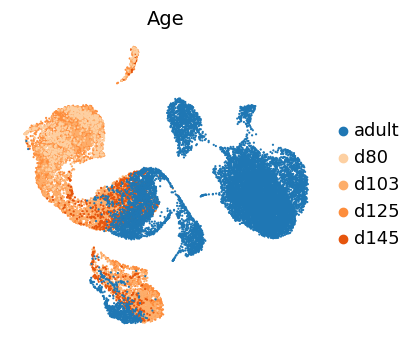

In [28]:
age_col = {'adult':'#1f77b4', 'd80':'#fdd0a2', 'd103':'#fdae6b', 'd125':'#fd8d3c', 'd145':'#e6550d'}

sc.pl.umap(adata, color=["Age"], 
           palette=age_col, ncols=5, frameon=False, size=10,
           save="lung_map2tissue_age.pdf")


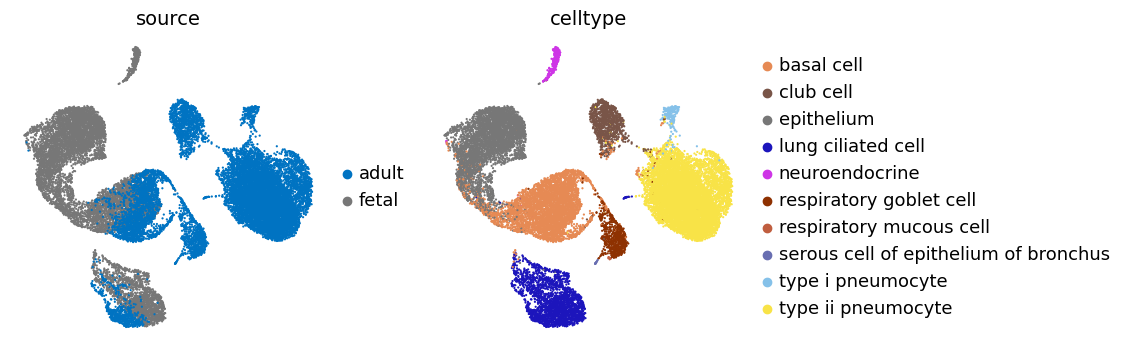

In [18]:
sc.pl.umap(adata, color=["source","celltype"], 
           palette=plate_level_all, ncols=5, frameon=False, size=10,
           save="lung_map2tissue_cts.pdf")


In [64]:
adata_org = sc.read_h5ad(f'/home/xuq44/projects/hgioa/revision2/results/lung_scpoli_reannot.h5ad')
adata_org = adata_org.raw.to_adata()

adata_org = anndata.AnnData.concatenate(*[adata_org, empty_adata], join='outer', fill_value=0)
adata_org = adata_org[:,[i for i in empty_adata.var.index if i in adata_org.var.index]]


In [65]:
adata_org.obs['Batch']=adata_org.obs['sample_id']
adata_org.obs['celltype']='na'


ref_path = f'/home/xuq44/projects/hgioa/revision2/data/lung_tissue/scpoli_ref/scpoli_model/'

scpoli_query = scPoli.load_query_data(
    adata=adata_org,
    reference_model=ref_path,
    labeled_indices=[],
)

early_stopping_kwargs = {
    "early_stopping_metric": "val_prototype_loss",
    "mode": "min",
    "threshold": 0,
    "patience": 20,
    "reduce_lr": True,
    "lr_patience": 13,
    "lr_factor": 0.1,
}

scpoli_query.train(
    n_epochs=12,
    pretraining_epochs=10,
    early_stopping_kwargs=early_stopping_kwargs,
    eta=10,
    alpha_epoch_anneal=100
)

#get latent representation of query data
data_latent= scpoli_query.get_latent(
    adata_org.X, 
    adata_org.obs["Batch"].values,
    mean=True
)

AnnData object with n_obs × n_vars = 221425 × 3000
    obs: 'initial_size_spliced', 'initial_size_unspliced', 'initial_size', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'pct_counts_hb', 'n_genes', 'sample_id', 'level_1_raw', 'level_2_raw', 'level_3_raw', 'sort_batch', 'Cell_type', 'n_counts', 'batch', 'publication', 'sample_name', 'tissue', 'derive', 'detail_tissue', 'time', 'time2', 'main_cells', 'protocol', 'tech', 'tech_detail', 'molecular', 'gel', 'conditions_combined', 'leiden', 'leiden_10.0', 'level_1', 'level_2', 'level_3', 'leiden_20.0', 'level_1_late', 'level_2_late', 'Batch', 'celltype'
    var: 'highly_variable-0', 'means-0', 'dispersions-0', 'dispersions_norm-0', 'highly_variable_nbatches-0', 'highly_variable_intersection-0'
    obsm: 'X_scPoli', 'X_umap', 'X_umap_min', 'X_umap_sc'
Embedding dictionary:
 	Num conditions: 56
 	Embedding dim: 3
Encoder Architecture:
	Input Layer in, out a

In [66]:

adata_latent = sc.AnnData(data_latent)
adata_latent.obs = adata_org.obs.copy()

umap_model = pickle.load(open(f"{out_dir}/scpoli_ref/umap_model.sav", 'rb'))
que_embedding = umap_model.transform(adata_latent.X)
adata_latent.obsm['X_umap'] = que_embedding

knn = KNeighborsClassifier(n_neighbors=100)
knn.fit(adata_latent_source.to_df(), 
    adata_latent_source.obs.celltype)

adata_latent.obs['predict_celltype'] = knn.predict(adata_latent.to_df())
knn_res = pd.DataFrame(knn.predict_proba(adata_latent.to_df()))
adata_latent.obs['predict_celltype_prob'] = knn_res.max(1).tolist()

knn = KNeighborsClassifier(n_neighbors=100)
knn.fit(adata_latent_source.to_df(), adata_latent_source.obs.source)

knn_res = pd.DataFrame(knn.predict_proba(adata_latent.to_df()))
knn_res.columns=['prob_'+i for i in knn.classes_]
knn_res.index=adata_latent.to_df().index

adata_latent.obs['predict_tissue'] = knn.predict(adata_latent.to_df())
adata_latent.obs = pd.merge(adata_latent.obs, knn_res, left_index=True, right_index=True)


In [9]:
# adata_latent.write_h5ad(f'/home/xuq44/projects/hgioa/revision2/results/lung_map2tissue.h5ad', compression="gzip")
adata_latent = sc.read_h5ad(f'/home/xuq44/projects/hgioa/revision2/results/lung_map2tissue.h5ad')


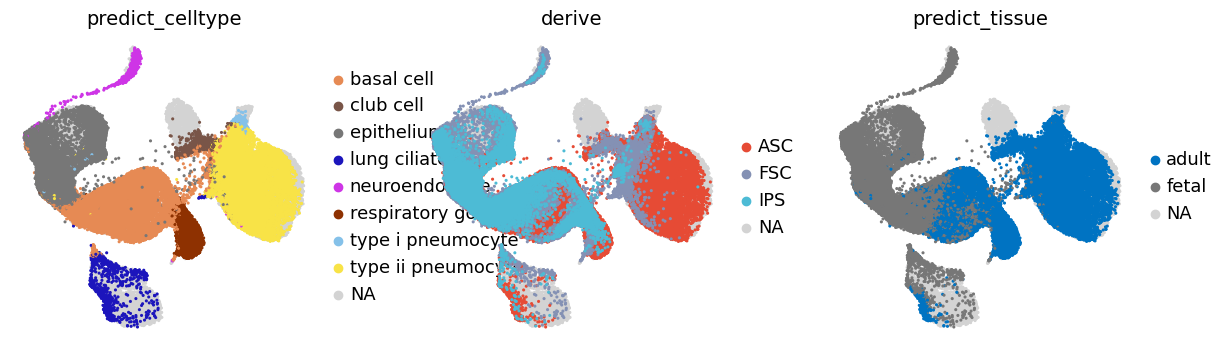

In [68]:
sc.pl.umap(anndata.AnnData.concatenate(*[adata, adata_latent], join='outer', fill_value=0), 
           color=["predict_celltype","derive","predict_tissue"], 
           palette=plate_level_all, ncols=5, frameon=False, size=20,
          save="lung_map2tissue_all.pdf")


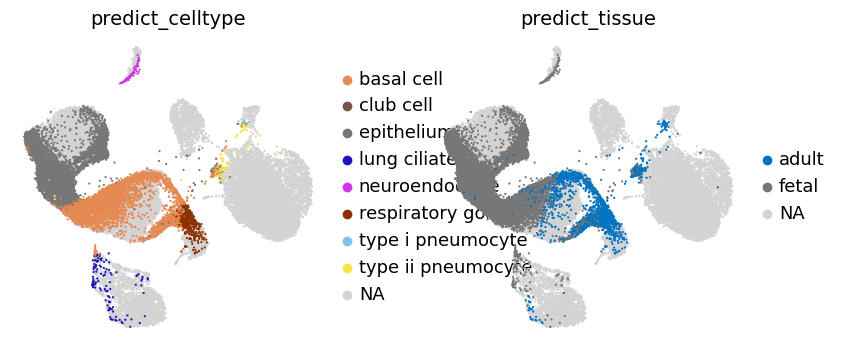

In [82]:
sc.pl.umap(anndata.AnnData.concatenate(*[adata, adata_latent[adata_latent.obs.derive=='IPS']], 
                                       join='outer', fill_value=0), 
           color=["predict_celltype","predict_tissue"], ncols=5, frameon=False, size=10,
           palette=plate_level_all, save="lung_map2tissue_IPS.pdf")


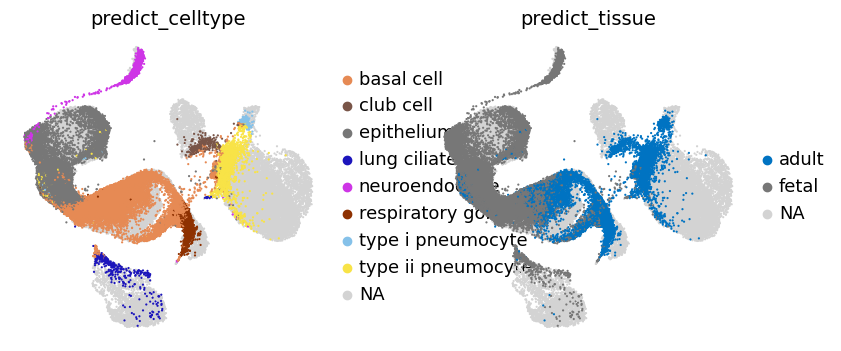

In [83]:
sc.pl.umap(anndata.AnnData.concatenate(*[adata, adata_latent[adata_latent.obs.derive=='FSC']], 
                                       join='outer', fill_value=0), 
           color=["predict_celltype","predict_tissue"], ncols=5, frameon=False, size=10,
           palette=plate_level_all, save="lung_map2tissue_FSC.pdf")


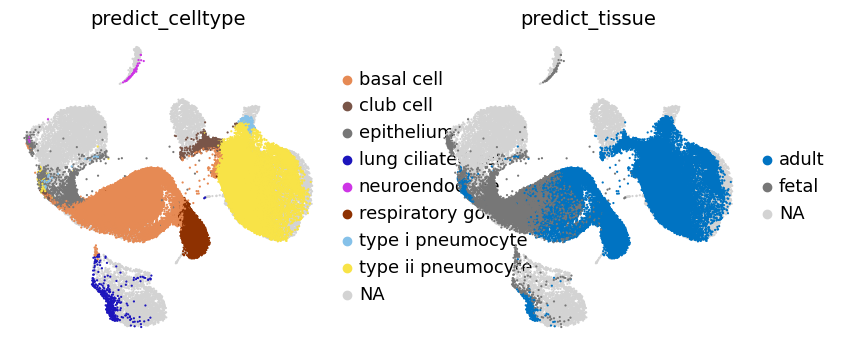

In [84]:
sc.pl.umap(anndata.AnnData.concatenate(*[adata, adata_latent[adata_latent.obs.derive=='ASC']], 
                                       join='outer', fill_value=0), 
           color=["predict_celltype","predict_tissue"], ncols=5, frameon=False, size=10,
           palette=plate_level_all,save="lung_map2tissue_ASC.pdf")


In [13]:
adata_latent2 = adata_latent[~adata_latent.obs.predict_celltype.isin(["lung ciliated cell","neuroendocrine"])].copy()

In [24]:
def plot_sub_mature(adata_latent2, source):

    adata_obs = adata_latent2[adata_latent2.obs.derive==source].obs

    cell_prop=pd.DataFrame()

    sample_ids=[]
    for i in adata_obs.sample_id.unique():
        sample_count = adata_obs[adata_obs.sample_id==i].groupby('predict_celltype')\
                    .count()['prob_adult']

        sample_count = pd.DataFrame(sample_count)
        cell_prop = pd.merge(cell_prop, sample_count, how='outer',
                                     left_index=True, right_index=True)

        cell_prop= cell_prop.fillna(0)
        cell_prop[i]=cell_prop['prob_adult']/sum(cell_prop['prob_adult'])
        cell_prop = cell_prop.drop('prob_adult', axis=1)

        sample_ids.append(i)

    cell_prop2 = cell_prop.T.copy()

    cell_prop2 = pd.merge(cell_prop2, pd.DataFrame(adata_obs[['sample_id']])\
                                  .reset_index(drop=True).drop_duplicates()\
                                  .set_index('sample_id'),
             left_index=True, right_index=True, how='left')


    plot_order = adata_obs.groupby('sample_id').median()[['prob_adult']].sort_values('prob_adult').index.tolist()
#     plot_order = cell_prop2.sort_values(['epithelium'], ascending=False).index.tolist()


    fig, axs = plt.subplots(2, 1, figsize=(cell_prop2.shape[0]*0.3, 5))
    mpl.rcParams['pdf.fonttype'] = 42

    cell_prop2 = cell_prop2.loc[plot_order]
    cell_prop2.plot.bar(stacked=True, ax=axs[0], width=0.7, 
                          color=plate_level_all
    )

    axs[0].legend().set_visible(False)
    axs[0].legend(bbox_to_anchor=(1, 0.8))

    axs[0].title.set_text('mapping annotation')
    axs[0].set(title=f'{source}-derived organoid cell proportion')
    axs[0].set_ylabel('Cell proportion')
    axs[0].set_xticklabels('');


    sns.boxplot(data=adata_obs, y='prob_adult', x='sample_id', order=plot_order, 
                color=plate_level_all[source], showfliers=False, ax=axs[1])
    axs[1].set_xticklabels('');
#     axs[1].set_ylim([0, 1])      

    return fig

def plot_sub_mature2(adata_latent2, source):

    adata_obs = adata_latent2[adata_latent2.obs.derive==source].obs

    cell_prop=pd.DataFrame()

    sample_ids=[]
    for i in adata_obs.sample_id.unique():
        sample_count = adata_obs[adata_obs.sample_id==i].groupby('predict_celltype')\
                    .count()['prob_adult']

        sample_count = pd.DataFrame(sample_count)
        cell_prop = pd.merge(cell_prop, sample_count, how='outer',
                                     left_index=True, right_index=True)

        cell_prop= cell_prop.fillna(0)
        cell_prop[i]=cell_prop['prob_adult']/sum(cell_prop['prob_adult'])
        cell_prop = cell_prop.drop('prob_adult', axis=1)

        sample_ids.append(i)

    cell_prop2 = cell_prop.T.copy()

    cell_prop2 = pd.merge(cell_prop2, pd.DataFrame(adata_obs[['sample_id']])\
                                  .reset_index(drop=True).drop_duplicates()\
                                  .set_index('sample_id'),
             left_index=True, right_index=True, how='left')


    plot_order = adata_obs.groupby('sample_id').median()[['prob_adult']].sort_values('prob_adult').index.tolist()
#     plot_order = cell_prop2.sort_values(['epithelium'], ascending=False).index.tolist()


    return adata_obs, plot_order


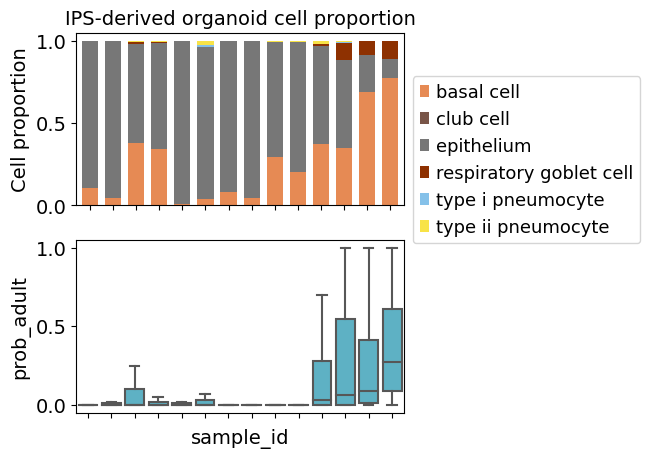

In [15]:
plot_sub_mature(adata_latent2, 'IPS').savefig(f"{figdir}/lung_IPS_fetal_adult_proportion.pdf", bbox_inches="tight")


In [25]:
aa,bb=plot_sub_mature2(adata_latent2, 'IPS')

'/'.join(map(str, aa[aa.sample_id.isin(bb)].\
             groupby('sample_id').count().loc[bb].n_genes_by_counts.tolist()))

'2768/1646/1695/1184/2949/1922/1946/8456/1401/1310/2770/1007/2186/2546'

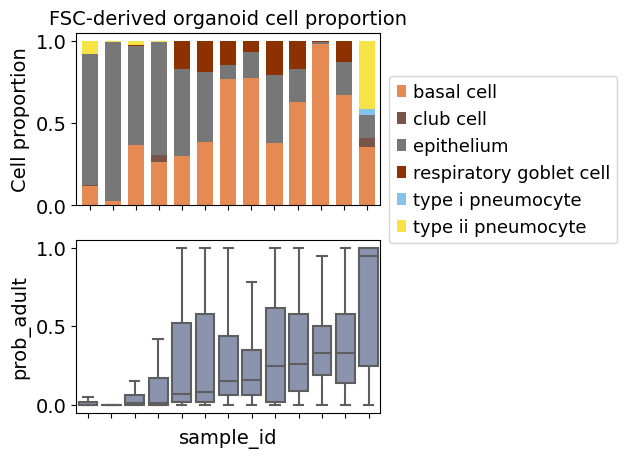

In [75]:
plot_sub_mature(adata_latent2, 'FSC').savefig(f"{figdir}/lung_FSC_fetal_adult_proportion.pdf", bbox_inches="tight")


In [26]:
aa,bb=plot_sub_mature2(adata_latent2, 'FSC')

'/'.join(map(str, aa[aa.sample_id.isin(bb)].\
             groupby('sample_id').count().loc[bb].n_genes_by_counts.tolist()))

'7933/10749/9763/2913/1223/917/9126/8800/395/9353/10070/5944/5588'

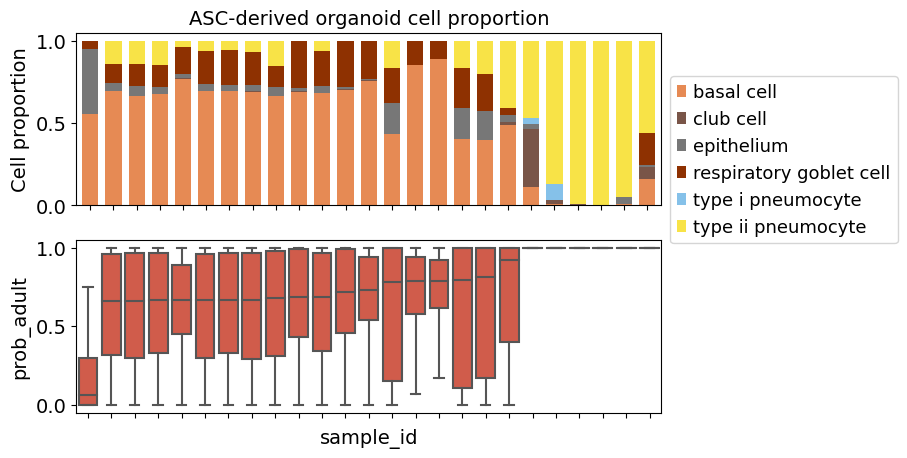

In [76]:
plot_sub_mature(adata_latent2, 'ASC').savefig(f"{figdir}/lung_ASC_fetal_adult_proportion.pdf", bbox_inches="tight")


In [27]:
aa,bb=plot_sub_mature2(adata_latent2, 'ASC')

'/'.join(map(str, aa[aa.sample_id.isin(bb)].\
             groupby('sample_id').count().loc[bb].n_genes_by_counts.tolist()))

'6872/1937/1773/1808/4766/1247/1110/1162/1945/2913/1190/6973/2952/702/3464/3870/742/462/1836/4145/8979/10909/13017/2560/396'

In [77]:
def get_ct_pect(adata, cell_type, source):
    adata = adata[adata.obs.derive==source]
    plot_order = adata.obs.groupby('sample_id').median()[['prob_adult']].sort_values('prob_adult').index.tolist()

    if cell_type=='all':
        xxxx = adata.obs.groupby(['sample_id','predict_tissue']).\
                count()['prob_adult'].reset_index()
    else:
        xxxx = adata[adata.obs.predict_primary_Cell_type==cell_type].\
                obs.groupby(['sample_id','predict_tissue']).\
                count()['prob_adult'].reset_index()

    xxxx = pd.merge(xxxx[xxxx.predict_tissue=='adult'], xxxx[xxxx.predict_tissue=='fetal'], on='sample_id')

    xxxx = xxxx.drop(columns=['predict_tissue_x','predict_tissue_y'])

    xxxx = xxxx.rename(columns={'prob_adult_x':'adult', 'prob_adult_y':'fetal'})
    xxxx['sum_num'] = xxxx.adult + xxxx.fetal
    xxxx['adult_pect'] = xxxx.adult/xxxx.sum_num
    xxxx['fetal_pect'] = xxxx.fetal/xxxx.sum_num
    xxxx = xxxx.set_index('sample_id')
    
    xxxx = pd.merge(xxxx, adata.obs[['sample_id']].drop_duplicates().set_index('sample_id'), 
                 left_index=True, right_index=True, how='outer')

    xxxx = xxxx.T[plot_order].loc[['fetal_pect','adult_pect']].T
    xxxx = xxxx.rename(columns={'fetal_pect':'fetal','adult_pect':'adult'})
    
    return xxxx

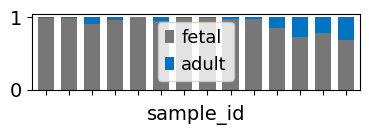

In [79]:
forplot = get_ct_pect(adata_latent2, 'all', "IPS")


fig, ax = plt.subplots(1, 1, figsize=(forplot.shape[0]*0.3, 1))

forplot.plot.bar(stacked=True, width=0.7, ax=ax, color=plate_level_all)
ax.set_xticklabels('');
fig.savefig(f"{figdir}/lung_IPS_fetal_adult_proportion2.pdf", bbox_inches="tight")


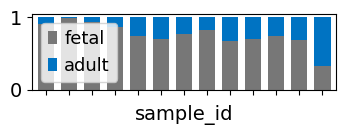

In [80]:
forplot = get_ct_pect(adata_latent2, 'all', "FSC")


fig, ax = plt.subplots(1, 1, figsize=(forplot.shape[0]*0.3, 1))

forplot.plot.bar(stacked=True, width=0.7, ax=ax, color=plate_level_all)
ax.set_xticklabels('');
fig.savefig(f"{figdir}/lung_FSC_fetal_adult_proportion2.pdf", bbox_inches="tight")


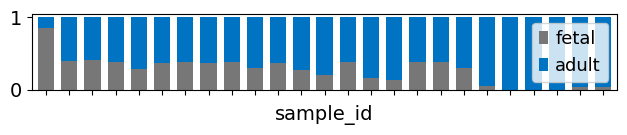

In [81]:
forplot = get_ct_pect(adata_latent2, 'all', "ASC")


fig, ax = plt.subplots(1, 1, figsize=(forplot.shape[0]*0.3, 1))

forplot.plot.bar(stacked=True, width=0.7, ax=ax, color=plate_level_all)
ax.set_xticklabels('');
fig.savefig(f"{figdir}/lung_ASC_fetal_adult_proportion2.pdf", bbox_inches="tight")
